## Noncompliance and Instruments



In [1]:
import polars as pl
import numpy as np
from plotnine import *

In [2]:
df = pl.read_csv("../data/prime_card.csv")
df.head()

age,income,credit_score,prime_elegible,prime_card,pv,tau,categ
f64,f64,f64,i64,i64,f64,f64,str
37.7,9687.0,822.0,0,0,4913.79,700.0,"""complier"""
46.0,13731.0,190.0,0,0,5637.66,200.0,"""never-taker"""
43.1,2839.0,214.0,1,1,2410.45,700.0,"""complier"""
36.0,1206.0,318.0,1,1,1363.06,700.0,"""complier"""
39.7,4095.0,430.0,0,0,2189.8,700.0,"""complier"""


## Extending Potential Outcomes

In [3]:
import statsmodels.formula.api as smf

# Nota: Convertimos de Polars a pandas porque statsmodels requiere pandas.
m = smf.ols("pv ~ prime_elegible", data=df.to_pandas()).fit()

# Mostramos la tabla de coeficientes del modelo
m.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,2498.3618,24.327,102.701,0.000,2450.677,2546.047
prime_elegible,321.3880,34.321,9.364,0.000,254.113,388.663


In [4]:
df.get_column("tau").mean()

413.45

In [5]:
m = smf.ols("pv~prime_card", data=df.to_pandas()).fit()
m.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,2534.4947,19.239,131.740,0.000,2496.783,2572.206
prime_card,588.1388,41.676,14.112,0.000,506.446,669.831


## Instrument Identification Assumptions

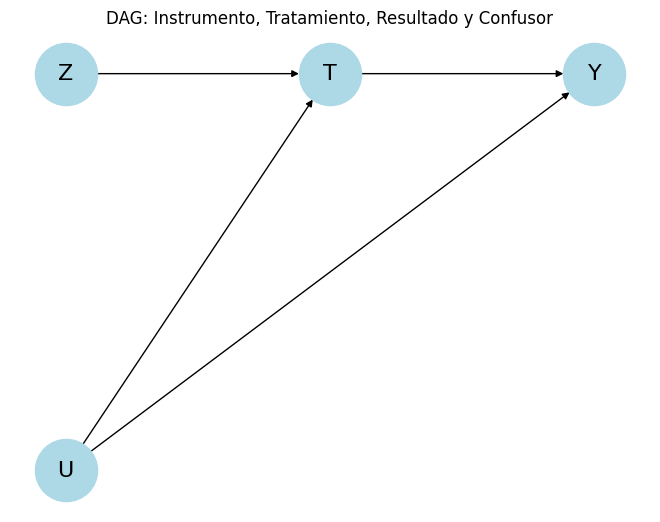

In [7]:
import networkx as nx

import matplotlib.pyplot as plt

# Creamos un grafo dirigido
G = nx.DiGraph()

# Añadimos nodos
G.add_nodes_from(['Z', 'T', 'Y', 'U'])

# Añadimos las aristas según el DAG
G.add_edges_from([
    ('Z', 'T'),   # Z → T
    ('T', 'Y'),   # T → Y
    ('U', 'T'),   # U → T
    ('U', 'Y')    # U → Y
])

# Dibujamos el DAG
pos = {'Z': (0, 1), 'U': (0, 0), 'T': (1, 1), 'Y': (2, 1)}
nx.draw(G, pos, with_labels=True, arrows=True, node_size=2000, node_color='lightblue', font_size=16)
plt.title("DAG: Instrumento, Tratamiento, Resultado y Confusor")
plt.show()

## First Stage

In [8]:
first_stage = smf.ols("prime_card ~ prime_elegible", data=df.to_pandas()).fit()
first_stage.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,1.369e-15,0.005,2.76e-13,1.000,-0.010,0.010
prime_elegible,0.4242,0.007,60.536,0.000,0.410,0.438


In [9]:
df.group_by("categ").agg(pl.len() / df.shape[0])

categ,len
str,f64
"""never-taker""",0.5731
"""complier""",0.4269


## Reduced Form

In [10]:
red_form = smf.ols("pv ~ prime_elegible", data=df.to_pandas()).fit()
red_form.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,2498.3618,24.327,102.701,0.000,2450.677,2546.047
prime_elegible,321.3880,34.321,9.364,0.000,254.113,388.663


In [11]:
late = red_form.params["prime_elegible"] / first_stage.params["prime_elegible"]
late

np.float64(757.6973795343814)

In [12]:
df.group_by("categ").agg(pl.mean("tau"))

categ,tau
str,f64
"""never-taker""",200.0
"""complier""",700.0


## Two-Stage Least Squares

In [21]:
iv_regr = smf.ols(
    "pv ~ prime_card",
    data=df.with_columns(
        prime_card=pl.Series(first_stage.fittedvalues)
    )
).fit()
iv_regr.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,2498.3618,24.327,102.701,0.000,2450.677,2546.047
prime_card,757.6974,80.914,9.364,0.000,599.091,916.304


In [14]:
first_stage.fittedvalues

0       1.368693e-15
1       1.368693e-15
2       4.241640e-01
3       4.241640e-01
4       1.368693e-15
            ...     
9995    4.241640e-01
9996    1.368693e-15
9997    4.241640e-01
9998    1.368693e-15
9999    4.241640e-01
Length: 10000, dtype: float64

## Standard Error

In [25]:
# SE IV (simple) usando el modelo iv_regr para predecir
# Clave: no mezclar polars.Series con pandas.Series; convertimos a NumPy.

Z = df.get_column("prime_elegible").to_numpy()
T = df.get_column("prime_card").to_numpy()
Y = df.get_column("pv").to_numpy()
n = df.height

# Predicción del modelo (statsmodels) -> numpy
Y_hat = iv_regr.predict(df.to_pandas())
Y_hat = np.asarray(Y_hat)

e_iv = Y - Y_hat

# compliance = Cov(T,Z) / Var(Z) (consistente con ddof=1 como en pandas/np.cov)
compliance = np.cov(T, Z, bias=False)[0, 1] / np.var(Z)

se = np.std(e_iv) / (compliance * np.std(Z) * np.sqrt(n))

print("SE IV:", se)
print("95% CI:", [late - 2*se, late + 2*se])

SE IV: 80.5205574003936
95% CI: [np.float64(596.6562647335942), np.float64(918.7384943351686)]


In [27]:
!uv pip install linearmodels

Using Python 3.12.12 environment at: C:\Users\evolu\Desktop\Master\Causal_Inference-with-python\.conda
Resolved 17 packages in 925ms
 Downloaded linearmodels
Prepared 7 packages in 1.60s
Installed 7 packages in 174ms
 + formulaic==1.2.1
 + interface-meta==1.3.0
 + linearmodels==7.0
 + mypy-extensions==1.1.0
 + narwhals==2.16.0
 + pyhdfe==0.2.0
 + wrapt==2.1.1


In [30]:
from linearmodels import IV2SLS

formula = 'pv ~ 1 + [prime_card ~ prime_elegible]'
iv_model = IV2SLS.from_formula(formula, df.to_pandas()).fit(cov_type="unadjusted")

iv_model.summary.tables[1]

,Parameter,Std. Err.,T-stat,P-value,Lower CI,Upper CI
Intercept,2498.4,24.211,103.19,0.0000,2450.9,2545.8
prime_card,757.70,80.529,9.4090,0.0000,599.86,915.53


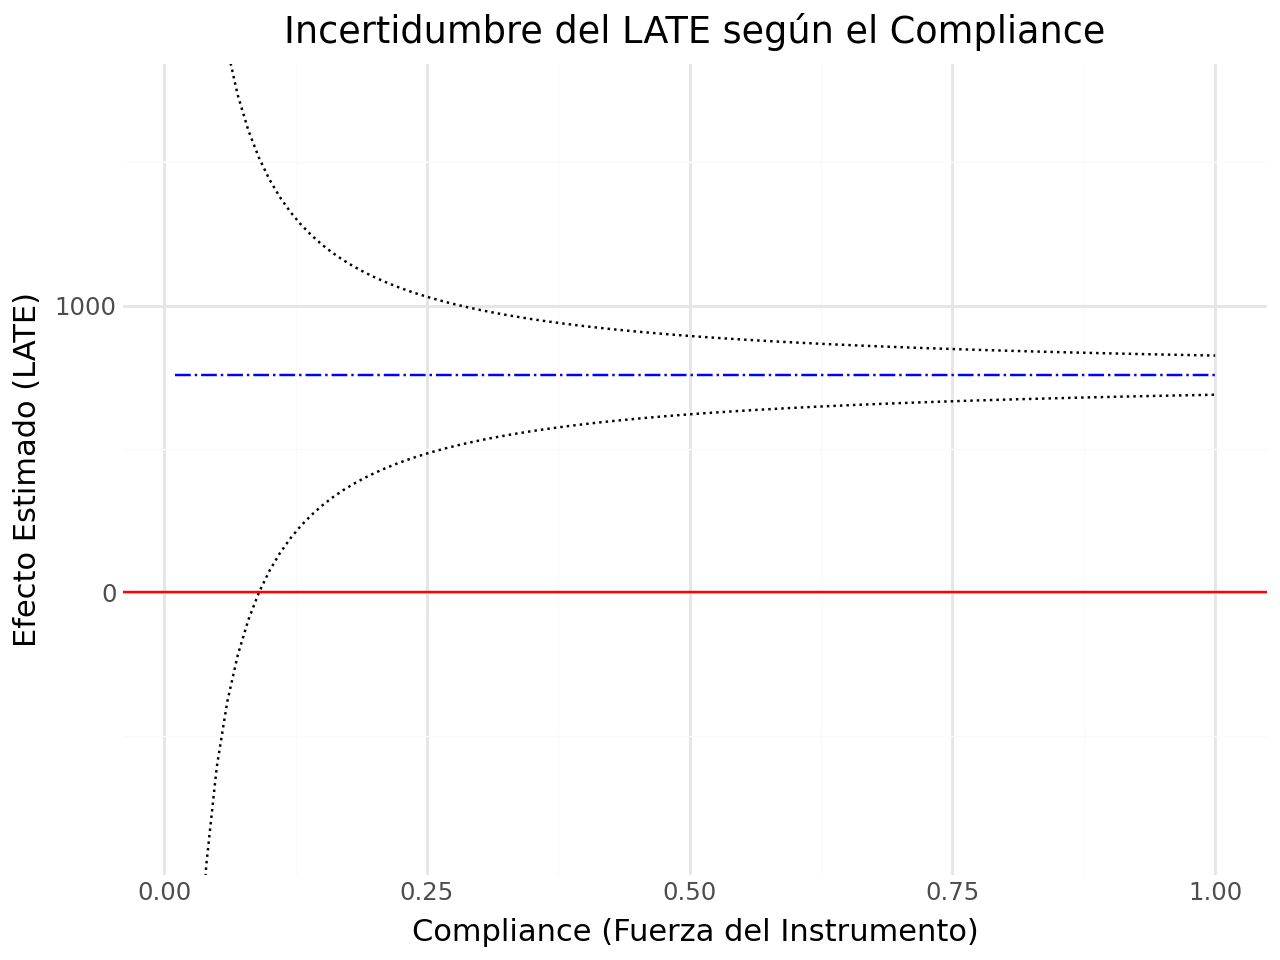

In [32]:

compliance_range = np.linspace(0.01, 1, 100)
std_e_iv = np.std(e_iv)
std_z = np.std(Z)

# Creamos un DataFrame con las métricas calculadas
df_sim = pl.DataFrame({
    "compliance": compliance_range,
    "late": [late] * 100
}).with_columns([
    (pl.col("late") - 2 * (std_e_iv / (pl.col("compliance") * std_z * np.sqrt(n)))).alias("ci_lower"),
    (pl.col("late") + 2 * (std_e_iv / (pl.col("compliance") * std_z * np.sqrt(n)))).alias("ci_upper"),
    (1 / (pl.col("compliance")**2)).alias("sample_size_ratio")
])

(
    ggplot(df_sim, aes(x="compliance"))
    + geom_line(aes(y="late"), linetype="dashdot", color="blue")
    + geom_line(aes(y="ci_upper"), linetype="dotted")
    + geom_line(aes(y="ci_lower"), linetype="dotted")
    + geom_hline(yintercept=0, color="red", size=0.5)
    + labs(
        title="Incertidumbre del LATE según el Compliance",
        x="Compliance (Fuerza del Instrumento)",
        y="Efecto Estimado (LATE)"
    )
    + coord_cartesian(ylim=(-(late + 100), (late + 100) * 2))
    + theme_minimal()
)




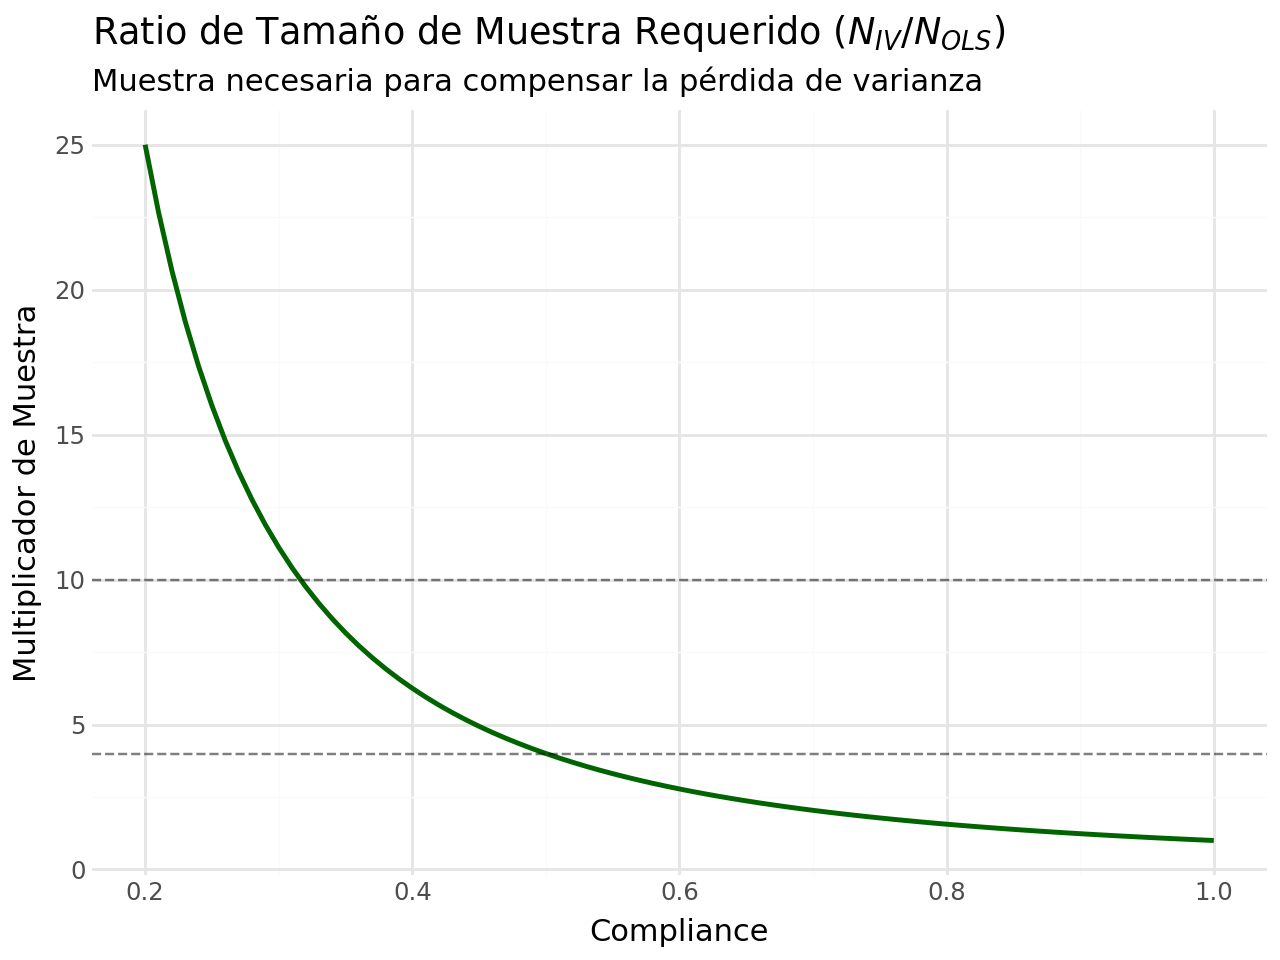

In [33]:
(
    ggplot(df_sim.filter(pl.col("compliance") >= 0.2), aes(x="compliance", y="sample_size_ratio"))
    + geom_line(color="darkgreen", size=1)
    + geom_hline(yintercept=[4, 10], linetype="dashed", alpha=0.5)
    + labs(
        title="Ratio de Tamaño de Muestra Requerido ($N_{IV} / N_{OLS}$)",
        subtitle="Muestra necesaria para compensar la pérdida de varianza",
        x="Compliance",
        y="Multiplicador de Muestra"
    )
    + theme_minimal()
)


## Additional Controls and Instruments

In [34]:
formula = 'pv ~ 1 + [prime_card ~ prime_elegible + credit_score]'
iv_model = IV2SLS.from_formula(formula, df.to_pandas()).fit(cov_type="unadjusted")
iv_model.summary.tables[1]

,Parameter,Std. Err.,T-stat,P-value,Lower CI,Upper CI
Intercept,2519.4,21.180,118.95,0.0000,2477.9,2560.9
prime_card,659.04,58.859,11.197,0.0000,543.68,774.41


In [35]:
formula = 'pv ~ 1 + [prime_card ~ prime_elegible + credit_score] + age + income'
iv_model = IV2SLS.from_formula(formula, df.to_pandas()).fit(cov_type="unadjusted")
iv_model.summary.tables[1]

,Parameter,Std. Err.,T-stat,P-value,Lower CI,Upper CI
Intercept,210.62,37.605,5.6008,0.0000,136.91,284.32
age,9.7444,0.8873,10.982,0.0000,8.0053,11.483
income,0.3998,0.0008,471.04,0.0000,0.3981,0.4014
prime_card,693.12,12.165,56.978,0.0000,669.28,716.96


## 2SLS by Hand

Since you won’t always have instrumental variable software at your disposal, I think it
is worth learning how to implement 2SLS by hand, especially since it is not at all
complicated. If you have more than one instrument and additional covariates, you
can include them in your model by:

1. **Primera etapa:** Regresa el tratamiento sobre los instrumentos y las covariables adicionales, es decir, $T \sim Z + X$.
2. **Segunda etapa:** Regresa el resultado sobre los valores ajustados del tratamiento (de la primera etapa) y las covariables adicionales, $Y \sim \hat{T} + X$.

---
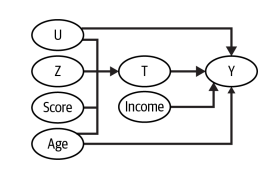


In [36]:
formula_1st = 'prime_card ~ prime_elegible + credit_score + age + income'
first_stage = smf.ols(formula_1st, data=df.to_pandas()).fit()
first_stage.summary().tables[1]

iv_model = smf.ols("pv ~ prime_card + income + age", data=df.with_columns(
    prime_card=pl.Series(first_stage.fittedvalues))).fit()

iv_model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,210.6177,40.832,5.158,0.000,130.578,290.657
prime_card,693.1207,13.209,52.474,0.000,667.229,719.013
income,0.3998,0.001,433.806,0.000,0.398,0.402
age,9.7444,0.963,10.114,0.000,7.856,11.633


## Matrix Implementation of 2SLS

La técnica de 2SLS (Two-Stage Least Squares) puede implementarse completamente usando álgebra lineal, lo que nos permite entender el proceso de estimación de los parámetros IV desde la base matemática. Primero, recordemos la intuición: queremos aislar la parte del tratamiento $T$ que es explicada por el instrumento $Z$ y los controles $X$, para luego usar esa "parte limpia" como predictor del resultado $Y$.

**Paso 1: Construcción de las matrices**

- $Z$ es la matriz de instrumentos y controles (incluyendo el intercepto).
- $X$ es la matriz de tratamiento y controles (incluyendo el intercepto).
- $Y$ es el vector de resultados.

**Paso 2: Proyección del tratamiento sobre los instrumentos**

La matriz proyectada $\hat{X}$ se obtiene como:

$$
\hat{X} = Z (Z'Z)^{-1} Z' X
$$

Esto significa que estamos usando $Z$ para predecir $X$ (tratamiento + controles), obteniendo los valores ajustados del tratamiento.

**Paso 3: Estimación de los parámetros IV**

Los coeficientes IV se calculan resolviendo:

$$
\hat{\beta}_{IV} = (\hat{X}'\hat{X})^{-1} \hat{X}'Y
$$

Esto es equivalente a una regresión OLS, pero usando los valores ajustados del tratamiento en vez de los observados.

**Resumen conceptual:**  
La matriz $Z$ "filtra" la variación exógena del tratamiento, y luego usamos esa variación para estimar el efecto causal sobre $Y$. Así, evitamos el sesgo por variables omitidas o endogeneidad.



In [38]:
Z = df[["prime_elegible", "credit_score", "income", "age"]].to_pandas().values
X = df[["prime_card", "income", "age"]].to_pandas().values
Y = df[["pv"]].to_pandas().values

def add_intercept(x):
    return np.concatenate([np.ones((x.shape[0], 1)), x], axis=1)

Z_ = add_intercept(Z)
X_ = add_intercept(X)

# pre-multiplying Z_.dot(...) last is important to avoid
# creating a huge NxN matrix
X_hat = Z_.dot(np.linalg.inv(Z_.T.dot(Z_)).dot(Z_.T).dot(X_))

b_iv = np.linalg.inv(X_hat.T.dot(X_hat)).dot(X_hat.T).dot(Y)
b_iv[1]

array([693.12072518])


**Fórmula matemática rigurosa:**  
La varianza del estimador IV, $\hat{\beta}_{IV}$, se calcula así:

$$
\operatorname{Var}(\hat{\beta}_{IV}) = \sigma^2_{e_{iv}} \cdot \operatorname{diag}\left( (\hat{X}'\hat{X})^{-1} \right)
$$

Donde:
- $\sigma^2_{e_{iv}}$ es la varianza de los residuos IV (la parte del resultado que no explica el modelo).
- $\hat{X}$ es la matriz de valores ajustados del tratamiento y controles (proyectados por los instrumentos).
- $(\hat{X}'\hat{X})^{-1}$ es la matriz inversa de la suma de productos cruzados de $\hat{X}$.
- $\operatorname{diag}(\cdot)$ significa que tomamos solo los elementos diagonales (la varianza de cada coeficiente).

**Interpretación:**  
Esto nos da la varianza de cada parámetro estimado por IV. Si el instrumento es débil, $\hat{X}'\hat{X}$ será pequeño y la varianza será grande.


In [39]:
e_hat_iv = (Y - X_.dot(b_iv))

var = e_hat_iv.var()*np.diag(np.linalg.inv(X_hat.T.dot(X_hat)))

np.sqrt(var[1])

np.float64(12.164694395031463)

> La fórmula de la varianza en notación matricial es rigurosa pero menos intuitiva. Para el caso **sin covariables adicionales**, podemos aproximar el error estándar del estimador IV de la siguiente manera:

$$
SE_{\hat{\beta}_{IV}} \approx \frac{\sigma_{e_{IV}}}{\sigma_{T} \cdot n \cdot R^2_{\text{1ra etapa}}}
$$

Donde:

- $\sigma_{e_{IV}}$ es la desviación estándar de los residuos del modelo IV (la parte del resultado no explicada por el modelo).
- $\sigma_{T}$ es la desviación estándar de los residuos del tratamiento, después de regresarlo sobre las covariables (pero **sin** incluir el instrumento).
- $n$ es el tamaño de la muestra.
- $R^2_{\text{1ra etapa}}$ es el coeficiente de determinación de la primera etapa (qué tan bien el instrumento predice el tratamiento).



In [43]:
t_tilde = smf.ols("prime_card ~ income + age", data=df).fit().resid

e_hat_iv.std()/(t_tilde.std()*np.sqrt(n*first_stage.rsquared))

np.float64(12.180626177625292)

Con esta fórmula, puedes ver que, aparte de aumentar el tamaño de la muestra, tienes tres palancas para disminuir el error estándar:

1. **Aumentar el $R^2$ de la primera etapa.** Esto se logra encontrando instrumentos fuertes, es decir, variables que predicen bien el tratamiento (compliance), pero cumplen la restricción de exclusión (no afectan el resultado directamente).
2. **Eliminar variables que predicen fuertemente $T$** para aumentar $\sigma_T$ (la desviación estándar del tratamiento después de ajustar por covariables).
3. **Disminuir el tamaño de los residuos de la segunda etapa**, lo cual se logra encontrando variables que predicen bien el resultado.

De esas tres palancas, confieso que solo me gusta la última. Como mencioné antes, es muy difícil encontrar buenos IVs en la práctica. Además, hay un límite en cuánto puedes eliminar para aumentar $\sigma_T$. Por lo tanto, la única manera confiable de reducir la varianza es encontrar variables que sean buenas para predecir el resultado.


## Discontinuity Design

La idea central es buscar una discontinuidad artificial en cómo se asigna un tratamiento. En lugar de un sorteo aleatorio, usamos un umbral o límite.

Imagina que el banco pone una regla: "Si tienes más de $5,000 USD en tu cuenta, no pagas comisión por la tarjeta Prime".

Grupo A: Personas con $4,999 USD (pagan comisión).

Grupo B: Personas con $5,001 USD (no pagan comisión).

Matemáticamente, asumimos que alguien con $4,999 es prácticamente igual a alguien con $5,001 en términos de comportamiento y riesgo. La única diferencia real es que uno cruzó el umbral y el otro no, lo que cambia drásticamente su probabilidad de aceptar la tarjeta.

### Supuestos del Diseño de Discontinuidad (RDD)

Para que el RDD identifique un efecto causal, necesitamos el **supuesto de suavidad** (*smoothness*). Este postula que las funciones de resultados potenciales y de tratamiento potencial deben ser continuas en el umbral $R=c$. Es decir, los individuos a ambos lados del límite deben ser comparables en sus características no observadas.

Formalmente, asumimos que:

$$ \lim_{r \to c^-} E[Y_t | R=r] = \lim_{r \to c^+} E[Y_t | R=r] $$
$$ \lim_{r \to c^-} E[T_z | R=r] = \lim_{r \to c^+} E[T_z | R=r] $$

### El Estimador LATE en RDD

Si estos supuestos se cumplen, el efecto identificado es el **Efecto Causal Promedio Local (LATE)**, calculado como el cociente entre el salto en el resultado observado ($Y$) y el salto en la probabilidad de tratamiento ($T$) al cruzar el umbral:

$$ LATE_{RDD} = \frac{\lim_{r \to c^+} E[Y|R=r] - \lim_{r \to c^-} E[Y|R=r]}{\lim_{r \to c^+} E[T|R=r] - \lim_{r \to c^-} E[T|R=r]} $$

### La Doble Localidad
Es crucial entender que este estimador tiene una naturaleza "doblemente local":
1.  **Localidad del Umbral:** El efecto solo es representativo para las unidades que se encuentran justo en el límite $R=c$.
2.  **Localidad del Instrumento:** Al igual que en variables instrumentales, solo mide el efecto para los *compliers* (aquellos que reciben el tratamiento **porque** cruzaron el umbral).

#### Intention to Treat Effect

In [44]:
df_dd = pl.read_csv("../data/prime_card_discontinuity.csv")
df_dd.head()

balance,prime_card,pv,tau,categ
f64,i64,f64,f64,str
12100.0,1,356.472,300.0,"""always-takers"""
4400.0,1,268.172,300.0,"""always-takers"""
4600.0,1,668.896,300.0,"""always-takers"""
3500.0,1,428.094,300.0,"""always-takers"""
12700.0,1,1619.793,700.0,"""complier"""


In [45]:
df_dd.get_column("tau").mean()

448.24

In [46]:
m = smf.ols(f"pv ~ balance * I(balance > 5000)", df_dd.to_pandas()).fit()
m.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,251.1350,19.632,12.792,0.000,212.655,289.615
I(balance > 5000)[T.True],354.7539,22.992,15.430,0.000,309.688,399.820
balance,0.0616,0.005,11.892,0.000,0.051,0.072
balance:I(balance > 5000)[T.True],-0.0187,0.005,-3.488,0.000,-0.029,-0.008


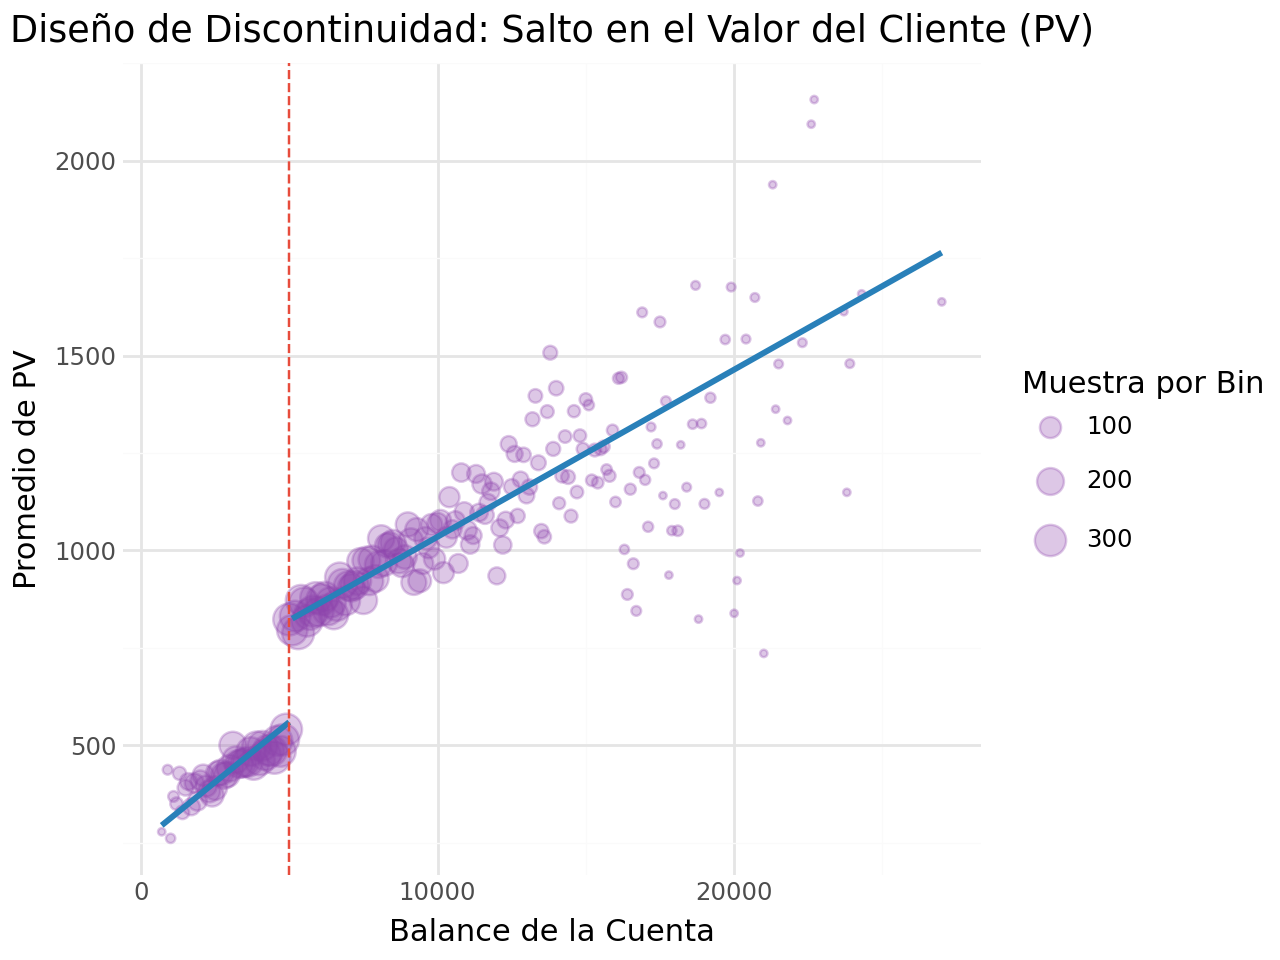

In [48]:
# 1. Procesamiento con Polars: redondear balance y agrupar
plt_df = (
    df_dd
    .with_columns(
        balance_bin=(pl.col("balance") / 100).round(0) * 100
    )
    .group_by("balance_bin")
    .agg(
        pl.col("pv").mean(),
        pl.len().alias("size")
    )
    .sort("balance_bin")
)

# 2. Generar predicciones para la línea (convertimos a pandas para statsmodels)
# Aseguramos que el nombre de la columna coincida con la fórmula del modelo 'm'
df_for_pred = plt_df.select(pl.col("balance_bin").alias("balance")).to_pandas()
plt_df = plt_df.with_columns(
    y_hat = pl.Series(m.predict(df_for_pred))
)

# 3. Graficar con plotnine
(
    ggplot(plt_df, aes(x="balance_bin", y="pv"))
    + geom_point(aes(size="size"), alpha=0.3, color="#8e44ad")
    + geom_line(
        aes(y="y_hat", group="balance_bin > 5000"), 
        color="#2980b9", 
        size=1.2
    )
    + geom_vline(xintercept=5000, linetype="dashed", color="#e74c3c")
    + labs(
        title="Diseño de Discontinuidad: Salto en el Valor del Cliente (PV)",
        x="Balance de la Cuenta",
        y="Promedio de PV",
        size="Muestra por Bin"
    )
    + theme_minimal()
)

## The IV Estimate

In [ ]:

def rdd_iv(data: pl.DataFrame, y: str, t: str, r: str, cutoff: float) -> float:
    """RDD fuzzy (Wald/IV local) con especificación lineal a ambos lados.

    1) Centramos el running variable: r := r - cutoff
    2) Definimos el "salto" en el cutoff: D = 1{r>0}
    3) Permitimos slopes distintos: rD = r * D
    4) LATE local = (coef D en Y~r+D+rD) / (coef D en T~r+D+rD)

    Nota: `statsmodels` requiere pandas, por eso convertimos al final.
    """
    required = {y, t, r}
    missing = required - set(data.columns)
    if missing:
        raise KeyError(f"Faltan columnas en data: {sorted(missing)}")

    df_c = (
        data
        .with_columns(
            (pl.col(r) - cutoff).alias(r),
            ((pl.col(r) - cutoff) > 0).cast(pl.Int8).alias("D"),
        )
        .with_columns(
            (pl.col(r) * pl.col("D")).alias("rD")
        )
        .select([y, t, r, "D", "rD"])
    )

    pdf = df_c.to_pandas()

    compliance = smf.ols(f"{t} ~ {r} + D + rD", data=pdf).fit()
    itte = smf.ols(f"{y} ~ {r} + D + rD", data=pdf).fit()

    return float(itte.params["D"] / compliance.params["D"])


rdd_iv(df_dd, y="pv", t="prime_card", r="balance", cutoff=5000)

732.8534752298924

In [52]:
# Al filtrar con múltiples condiciones en Polars, siempre debemos usar paréntesis
# para asegurar que las comparaciones se evalúen antes que el operador lógico `&`.
(
    df_dd.with_columns(
        balance_bin=(pl.col("balance") / 100).round(0) * 100
    )
    .filter(
        (pl.col("balance") == 5000) & 
        (pl.col("categ") == "complier")
    )
).get_column("tau").mean()

700.0

In [54]:
from joblib import Parallel, delayed
from toolz import partial

def bootstrap(data, est_fn, rounds=200, seed=123, pcts=[2.5, 97.5]):
    np.random.seed(seed)
    
    # En Polars usamos 'fraction' en lugar de 'frac' 
    # y 'with_replacement' para el remuestro (bootstrap)
    stats = Parallel(n_jobs=4)(
        delayed(est_fn)(data.sample(fraction=1.0, with_replacement=True))
        for _ in range(rounds)
    )
    
    return np.percentile(stats, pcts)

# Ejecutamos el bootstrap para el estimador RDD-IV
bootstrap(df_dd,
          partial(rdd_iv, y="pv", t="prime_card", r="balance", cutoff=5000))

array([670.14162488, 788.83488694])

## Key Ideas

1. **El Problema: No Cumplimiento (Noncompliance)**  
El capítulo explica que el "No Cumplimiento" ocurre cuando las personas pueden elegir no tomar un tratamiento que se les asignó. En tu caso, es cuando mandas la instrucción de carga pero el monitorista no la abre o el chofer la ignora. Esto "ensucia" el análisis porque la decisión humana se mezcla con el efecto real del ahorro.

2. **Los 4 tipos de personas (Grupos de Cumplimiento)**  
Para entender tus datos, debes saber que tu flota se divide en estos grupos:
- **Compliers (Cumplidores):** Los que van a la estación solo porque tú se los pediste. Son los más importantes para tu análisis.
- **Always-takers (Siempre-tomadores):** Choferes que siempre cargan en esa estación, les mandes mensaje o no.
- **Never-takers (Nunca-tomadores):** Choferes que jamás irán a esa estación, aunque les ruegues.
- **Defiers (Rebeldes):** Aquellos que hacen exactamente lo contrario a lo que les pides.

3. **La Solución: Variables Instrumentales ($Z$)**  
Aprendiste que un Instrumento ($Z$) (tu mensaje de n8n) es una variable que cumple dos reglas:
- Impacta el tratamiento (la carga) de forma no sesgada.
- No impacta el resultado (ahorro) directamente, sino solo a través de la acción de cargar.

Si asumes que no hay rebeldes (**Monotonicidad**), puedes usar el Estimador de Wald para "limpiar" el efecto:

$$
Efecto\ Real = \frac{Efecto\ del\ Mensaje\ (ITT)}{Tasa\ de\ Cumplimiento}
$$

Es decir, divides el ahorro promedio entre el porcentaje de gente que te hizo caso.

4. **El Costo de la "Desobediencia" (Varianza)**  
Este es el punto que más te afecta: si el cumplimiento es bajo, necesitas muchísimos más datos.  
Si solo el 50% de los choferes te hace caso, necesitas 4 veces más recargas para estar seguro del resultado.

> **Truco para ahorrar tiempo:** Agregar variables que predigan bien el resultado (como el peso de la carga o el modelo del camión) ayuda a reducir este margen de error drásticamente.

5. **Regresión Discontinua (RDD)**  
Vimos que las reglas arbitrarias (como "solo cargan aquí los que lleguen después de las 6:00 PM") funcionan como experimentos naturales. Puedes comparar a los que están "apenas antes" contra los que están "apenas después" del límite para medir el efecto, tratándolo como un instrumento más.